In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [22]:
df = pd.read_csv('house_data.csv')

In [23]:
df.head()

,size_sqft,bedrooms,age_years,price_lakh
0,650,1,12,28.5
1,800,2,8,35.2
2,950,2,5,42.0
3,1100,3,10,50.5
4,1250,3,7,58.3


In [24]:
df.describe()

,size_sqft,bedrooms,age_years,price_lakh
count,50.00000,50.000000,50.000000,50.000000
mean,1364.40000,3.240000,6.580000,62.478000
std,440.16305,1.187692,4.422069,22.096387
min,650.00000,1.000000,1.000000,26.000000
25%,975.00000,2.000000,3.000000,42.550000
50%,1370.00000,3.000000,6.000000,62.500000
75%,1715.00000,4.000000,9.000000,79.950000
max,2200.00000,5.000000,20.000000,102.000000


In [25]:
df.isnull().sum()

size_sqft     0
bedrooms      0
age_years     0
price_lakh    0
dtype: int64

In [26]:
df.describe().round(2)

,size_sqft,bedrooms,age_years,price_lakh
count,50.00,50.00,50.00,50.00
mean,1364.40,3.24,6.58,62.48
std,440.16,1.19,4.42,22.10
min,650.00,1.00,1.00,26.00
25%,975.00,2.00,3.00,42.55
50%,1370.00,3.00,6.00,62.50
75%,1715.00,4.00,9.00,79.95
max,2200.00,5.00,20.00,102.00


In [27]:
X=df.iloc[:,:3]

In [28]:
X.head()

,size_sqft,bedrooms,age_years
0,650,1,12
1,800,2,8
2,950,2,5
3,1100,3,10
4,1250,3,7


In [29]:
y=df.iloc[:,-1]

In [30]:
y.head()

0    28.5
1    35.2
2    42.0
3    50.5
4    58.3
Name: price_lakh, dtype: float64

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [32]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [33]:
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std on train
X_test_scaled  = scaler.transform(X_test)

In [34]:
X_train_scaled

array([[-0.79583953, -1.0174601 ,  0.4323377 ],
       [-0.18410774, -0.13271219,  0.        ],
       [ 0.85113068,  0.75203572, -0.8646754 ],
       [ 1.22758101,  0.75203572, -1.08084425],
       [-0.53702993, -0.13271219,  0.64850655],
       [ 0.52173663,  0.75203572, -0.21616885],
       [-1.00759285, -1.0174601 ,  0.64850655],
       [ 0.75701809,  0.75203572, -0.8646754 ],
       [ 1.10994028,  0.75203572, -1.08084425],
       [ 0.28645518,  0.75203572,  0.21616885],
       [ 1.5805032 ,  1.63678363, -1.2970131 ],
       [ 0.63937736,  0.75203572, -0.4323377 ],
       [-0.1135233 , -0.13271219,  0.4323377 ],
       [-0.23116403, -0.13271219,  0.21616885],
       [-1.12523357, -1.0174601 ,  0.        ],
       [-1.59579649, -1.90220801,  1.08084425],
       [ 0.05117372, -0.13271219, -0.64850655],
       [ 0.92171511,  0.75203572, -0.64850655],
       [-0.58408622, -0.13271219,  0.4323377 ],
       [ 0.16881445, -0.13271219, -0.64850655],
       [ 1.69814393,  1.63678363, -1.297

In [35]:
X_test_scaled

array([[-0.4193892 , -0.13271219, -0.21616885],
       [ 1.62755949,  1.63678363, -1.2970131 ],
       [-1.47815576, -1.90220801,  0.64850655],
       [ 0.4040959 ,  0.75203572, -0.21616885],
       [ 0.99229955,  0.75203572, -0.64850655],
       [ 1.46286247,  1.63678363, -1.08084425],
       [ 0.59232107,  0.75203572, -0.4323377 ],
       [ 0.21587074, -0.13271219,  0.        ],
       [-0.96053655, -1.0174601 , -0.21616885],
       [ 1.81578466,  1.63678363, -1.08084425]])

In [36]:
from sklearn.linear_model import LinearRegression

LR=LinearRegression()

In [37]:
LR.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
from sklearn.metrics import mean_squared_error,r2_score

In [40]:
y_pred_sklearn = LR.predict(X_test_scaled)
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
r2_sklearn  = r2_score(y_test, y_pred_sklearn)

In [41]:
y_pred_sklearn
mse_sklearn
r2_sklearn

0.9981417587753806

In [43]:
new_houses = np.array([
    [1200, 3, 5],   # 1200 sqft, 3 bed, 5 years old
    [1800, 4, 2],   # 1800 sqft, 4 bed, 2 years old
    [900,  2, 10],
    [1500,7,3]    # 900 sqft,  2 bed, 10 years old
])
 
new_scaled = scaler.transform(new_houses)
preds = LR.predict(new_scaled)
 
print(f"\n  {'Size':>8}  {'Beds':>6}  {'Age':>6}  {'Predicted Price':>16}")
print("  " + "-" * 42)
for house, pred in zip(new_houses, preds):
    print(f"  {house[0]:>8} sqft  {house[1]:>2} bed  {house[2]:>3} yr  ₹ {pred:.2f} Lakh")


      Size    Beds     Age   Predicted Price
  ------------------------------------------
      1200 sqft   3 bed    5 yr  ₹ 55.01 Lakh
      1800 sqft   4 bed    2 yr  ₹ 84.31 Lakh
       900 sqft   2 bed   10 yr  ₹ 39.42 Lakh
      1500 sqft   7 bed    3 yr  ₹ 70.55 Lakh


/home/hodorinfo4/Desktop/Machine Learning/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  Saved: linear_regression_results.png


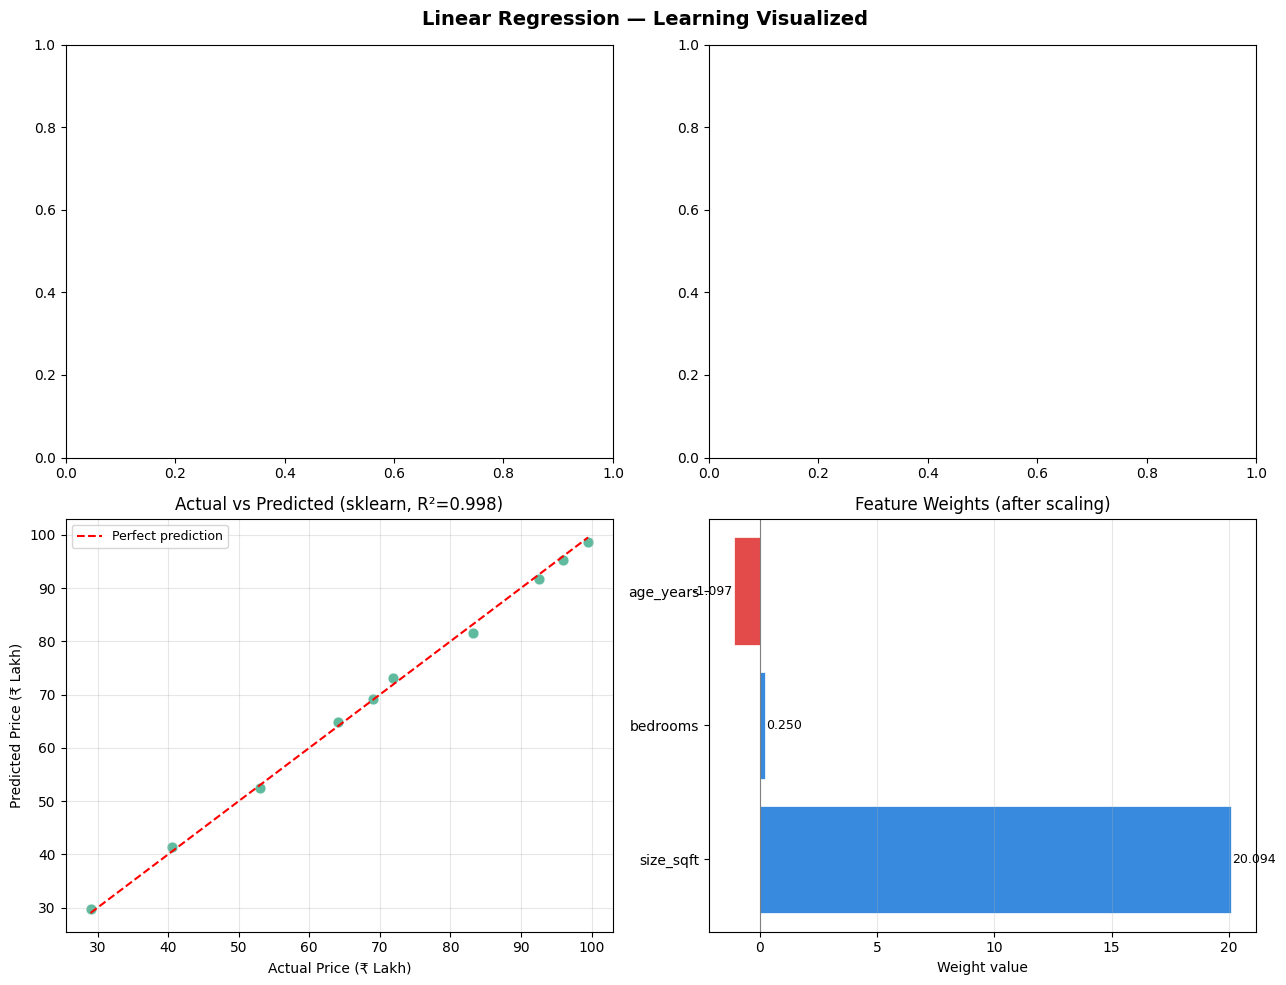

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Linear Regression — Learning Visualized", fontsize=14, fontweight="bold")
mn = y_test.min()
mx = y_test.max()
 
ax3 = axes[1, 0]
ax3.scatter(y_test, y_pred_sklearn, alpha=0.7, color="#1d9e75", edgecolors="white", linewidth=0.5, s=60)
ax3.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect prediction")
ax3.set_title(f"Actual vs Predicted (sklearn, R²={r2_sklearn:.3f})")
ax3.set_xlabel("Actual Price (₹ Lakh)")
ax3.set_ylabel("Predicted Price (₹ Lakh)")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)


ax4 = axes[1, 1]
features = ["size_sqft", "bedrooms", "age_years"]
weights  = LR.coef_
colors   = ["#378add" if w > 0 else "#e24b4a" for w in weights]
bars = ax4.barh(features, weights, color=colors, edgecolor="white", linewidth=0.5)
ax4.axvline(0, color="gray", linewidth=0.8)
ax4.set_title("Feature Weights (after scaling)")
ax4.set_xlabel("Weight value")
ax4.grid(alpha=0.3, axis="x")
for bar, val in zip(bars, weights):
    ax4.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)
 
plt.tight_layout()
plt.savefig("linear_regression_results.png", dpi=130, bbox_inches="tight")
print("  Saved: linear_regression_results.png")
plt.show()